In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


In [13]:
# SASBDB comparison

# import proteins and load polymer data
proteins = pd.read_excel('../data/SASBDB_database.xlsx')
polymers = pd.read_excel('../data/Featurized Polymer SAXS Data.xlsx')

# remove any polymer samples where Final Rg is NaN or -1
polymers = polymers[polymers['Final Rg'].notna()]
polymers = polymers[polymers['Final Rg'] != -1]
#polymers = polymers[polymers['Final Rg'] > 15]

polymers = polymers[polymers['GMM Cluster'].notna()]
proteins = proteins[proteins['Cluster'].notna()]

In [14]:
# make a new dictionary for the morphology classification from GMM cluster
morphology_dict = {
    3: 'globular',
    1: 'multidomain',
    0: 'folded',
    4: 'flexible',
    2: 'disordered'
}

# add a new column to polymers and proteins for their morphology
polymers['morphology'] = polymers['GMM Cluster'].map(morphology_dict)
proteins['morphology'] = proteins['Cluster'].map(morphology_dict)

# make a new dictionary for order number based on morphology column
order_dict = {
    'multidomain': 1,
    'globular': 0,
    'folded': 2,
    'flexible': 3,
    'disordered': 4
}

# add a new column to polymers and proteins for their order number
polymers['folding order'] = polymers['morphology'].map(order_dict)
proteins['folding order'] = proteins['morphology'].map(order_dict)

Median Rg for proteins: 33.73 Å
Median Rg for polymers: 66.33 Å
Protein Rg - Min: 9.39 Å, Max: 115.33 Å, Average: 37.35 Å
Polymer Rg - Min: 19.23 Å, Max: 122.72 Å, Average: 70.73 Å


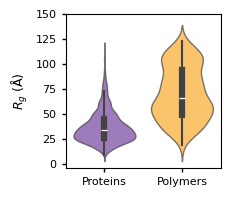

Number of proteins: 3322 Number of polymers: 384


In [15]:

# median Rg for polymers and proteins
protein_median_rg = proteins['Rg'].median()
polymer_median_rg = polymers['Final Rg'].median()

# print the min, max, and average Rg for proteins and polymers
protein_min_rg = proteins['Rg'].min()
protein_max_rg = proteins['Rg'].max()
protein_avg_rg = proteins['Rg'].mean()

polymer_min_rg = polymers['Final Rg'].min()
polymer_max_rg = polymers['Final Rg'].max()
polymer_avg_rg = polymers['Final Rg'].mean()

print(f'Median Rg for proteins: {protein_median_rg:.2f} Å')
print(f'Median Rg for polymers: {polymer_median_rg:.2f} Å')
print(f'Protein Rg - Min: {protein_min_rg:.2f} Å, Max: {protein_max_rg:.2f} Å, Average: {protein_avg_rg:.2f} Å')
print(f'Polymer Rg - Min: {polymer_min_rg:.2f} Å, Max: {polymer_max_rg:.2f} Å, Average: {polymer_avg_rg:.2f} Å')

# boxplot of Rg for polymers and proteins


# Set matplotlib rcParams to ensure tick marks show
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.direction'] = 'out'
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2

sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]
# protein color:
protein_color = sunset[7]
polymer_color = sunset[2]

# Use original colors without alpha - let violinplot handle transparency
palette = [protein_color, polymer_color]

#violin plot of Rg for polymers and proteins with colors
fig, ax = plt.subplots(figsize=(2,2))

# Use seaborn with alpha parameter instead of pre-setting alpha in colors
sns.violinplot(data=[proteins['Rg'], polymers['Final Rg']], palette=palette, alpha=0.7, linewidth=1, ax=ax, saturation=1)

plt.xticks([0, 1], ['Proteins', 'Polymers'], fontsize=8)  
plt.yticks([0,25,50,75,100,125, 150],fontsize=8)  
plt.ylabel('$R_g$ (Å)', fontsize=9)

# Force override of seaborn tick settings - this should work!
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
ax.xaxis.set_tick_params(direction='out', length=3, width=1, which='major')
ax.yaxis.set_tick_params(direction='out', length=3, width=1, which='major')

plt.show()

fig.savefig('../imgs/protein comparison/protein polymer comparison Rg violin plot.svg', dpi=600, bbox_inches='tight', transparent=True)


print(f"Number of proteins: {len(proteins)}", f"Number of polymers: {len(polymers)}")

c:\Users\Elena\OneDrive - Rutgers University\Documents\VS Code\1. SCNP Modeling 04_27_2026\.venv_models\Lib\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


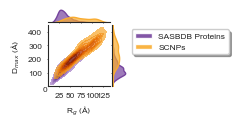

In [18]:
# Alternative approach using seaborn JointGrid (often easier to work with)

# Prepare combined dataset for easier plotting
proteins_plot = proteins[['Dmax', 'Rg']].copy()
proteins_plot['Source'] = 'SASBDB Proteins'
proteins_plot = proteins_plot.rename(columns={'Rg': 'Radius_of_Gyration'})

polymers_plot = polymers[['Dmax', 'Final Rg']].copy()
polymers_plot['Source'] = 'SCNPs'
polymers_plot = polymers_plot.rename(columns={'Final Rg': 'Radius_of_Gyration'})

# Combine datasets
combined_data = pd.concat([proteins_plot, polymers_plot], ignore_index=True)

# Create JointGrid
g = sns.JointGrid(data=combined_data, y='Dmax', x='Radius_of_Gyration', height=1, ratio=4)

# Main plot with custom colormaps
sns.kdeplot(data=proteins, y='Dmax', x='Rg', fill=True, cmap=protein_cmap, 
            alpha=0.9, ax=g.ax_joint)
sns.kdeplot(data=polymers, y='Dmax', x='Final Rg', fill=True, cmap=polymer_cmap, 
            alpha=0.7, ax=g.ax_joint)

# Marginal plots
sns.kdeplot(data=proteins, y='Dmax', fill=True, color='#75439D', alpha=0.7, 
            ax=g.ax_marg_y, label='SASBDB Proteins')
sns.kdeplot(data=polymers, y='Dmax', fill=True, color='#F9AC2F', alpha=0.7, 
            ax=g.ax_marg_y, label='SCNPs')

sns.kdeplot(data=proteins, x='Rg', fill=True, color='#75439D', alpha=0.7, 
            ax=g.ax_marg_x)
sns.kdeplot(data=polymers, x='Final Rg', fill=True, color='#F9AC2F', alpha=0.7, 
            ax=g.ax_marg_x)

# Formatting
g.ax_joint.set_ylabel('D$_{max}$ (Å)', fontsize=6)
g.ax_joint.set_xlabel('R$_g$ (Å)', fontsize=6)
g.ax_joint.set_ylim(0, 450)
g.ax_joint.set_xlim(0, 140)

# Method 1: Using set_xticklabels and set_yticklabels
g.ax_joint.set_yticks([100, 200, 300, 400])
g.ax_joint.set_yticklabels([100, 200, 300, 400], fontsize=6)
g.ax_joint.set_xticks([25, 50, 75, 100, 125])
g.ax_joint.set_xticklabels([25, 50, 75, 100, 125], fontsize=6)

# Add tick marks on all four edges of the plot - main plot gets bottom and left
g.ax_joint.tick_params(axis='both', which='major', 
                       top=False, right=False, bottom=True, left=True,
                       direction='out', length=1, width=0.5)

# Add tick marks to marginal plots to get flush top and right edges
# Top marginal plot - add ticks on bottom edge (x-axis)
g.ax_marg_x.tick_params(axis='x', which='major', 
                        bottom=True, top=False,
                        direction='out', length=1, width=0.5)
g.ax_marg_x.set_xticks([25, 50, 75, 100, 125])  # Match main plot x-ticks

# Right marginal plot - add ticks on left edge (y-axis)  
g.ax_marg_y.tick_params(axis='y', which='major',
                        left=True, right=False, 
                        direction='out', length=1, width=0.5)
g.ax_marg_y.set_yticks([100, 200, 300, 400])  # Match main plot y-ticks

# Add "0" label at the bottom-left corner (origin) without adding it as a tick
g.ax_joint.text(-2, -2, '0', fontsize=6, ha='right', va='top', 
                transform=g.ax_joint.transData, 
                bbox=dict(boxstyle='round,pad=0.1', facecolor='none', alpha=0.8, edgecolor='none'))

# Add manual legend (since JointGrid doesn't handle legends as nicely)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75439D', alpha=0.9, label='SASBDB Proteins'),
    Patch(facecolor='#F9AC2F', alpha=0.9, label='SCNPs')
]
g.ax_joint.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(3, 1), fontsize=6, 
                  frameon=True, fancybox=True, shadow=True)

plt.show()

# Save the plot
g.fig.savefig('../imgs/protein comparison/joint Dmax Rg.svg', dpi=600, bbox_inches='tight', transparent=True)

<>:51: SyntaxWarning: invalid escape sequence '\i'
<>:51: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Elena\AppData\Local\Temp\ipykernel_34336\3910952251.py:51: SyntaxWarning: invalid escape sequence '\i'
  fig.savefig('..\imgs\protein comparison\protein polymer Kratky cluster distribution.svg', dpi=600, bbox_inches='tight', transparent=True)


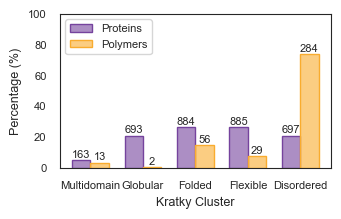

In [21]:
# bar plot comparison of Kratky classifications between proteins and polymers

cluster_labels_dict = {
    1: 'Multidomain',
    3: 'Globular',
    0: 'Folded',
    4: 'Flexible',
    2: 'Disordered'}


protein_counts = proteins['Cluster'].map(cluster_labels_dict).value_counts().reindex(cluster_labels_dict.values())
polymer_counts = polymers['GMM Cluster'].map(cluster_labels_dict).value_counts().reindex(cluster_labels_dict.values())

# Calculate percentages
protein_percentages = (protein_counts / len(proteins)) * 100
polymer_percentages = (polymer_counts / len(polymers)) * 100

x = np.arange(len(cluster_labels_dict))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(3.5, 2))
from matplotlib.colors import to_rgba
# Create bars with transparent fill but solid edges
protein_color = '#75439D'
polymer_color = '#F9AC2F'
rects1 = ax.bar(x - width/2, protein_percentages, width, label='Proteins', 
                facecolor=to_rgba(protein_color, .6), edgecolor=protein_color, linewidth=1)
rects2 = ax.bar(x + width/2, polymer_percentages, width, label='Polymers', 
                facecolor=to_rgba(polymer_color, .6), edgecolor=polymer_color, linewidth=1)

# Add count labels on top of bars
for i, rect in enumerate(rects1):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 0.25,
            f'{protein_counts.iloc[i]}', ha='center', va='bottom', fontsize=8)

for i, rect in enumerate(rects2):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 0.25,
            f'{polymer_counts.iloc[i]}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Percentage (%)', fontsize=9)
ax.set_xlabel('Kratky Cluster', fontsize=9)
#ax.set_title('Cluster Distribution for Proteins and Polymers', fontsize=6)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.tick_params(axis='y', labelsize=8)
ax.set_xticks(x)
ax.set_xticklabels(cluster_labels_dict.values(), fontsize=8)
ax.legend(fontsize=8)

# save image in high resolution (600 dpi) with a transparent background in the img folder
fig.savefig('..\imgs\protein comparison\protein polymer Kratky cluster distribution.svg', dpi=600, bbox_inches='tight', transparent=True)